# Finetunning de Stable Diffusion para Portadas de Libros Antiguos
## Máster en Inteligencia Artificial, Cloud Computing y DevOps
## Módulo: Generacion de Imagenes con AI
## Autor: Alexander De Sousa

Este notebook documenta el proceso completo de finetuning de un modelo de difusión (Stable Diffusion 1.5) utilizando un dataset de ilustraciones y portadas de libros antiguos.  
El objetivo es adaptar el modelo base para que aprenda el estilo visual característico de este tipo de obras, generando imágenes coherentes, estilizadas y reproducibles.

El trabajo incluye:

- Preparación y preprocesamiento del dataset.
- Entrenamiento completo del modelo (UNet) y entrenamiento mediante LoRA.
- Comparación entre resultados antes y después del finetuning.
- Evaluación cualitativa del estilo aprendido.
- Publicación del modelo en Hugging Face para su reutilización.

Este documento constituye la entrega final del módulo de Generación de Imágenes con IA.
---


#### 1. Instalación de dependencias
Instalamos las librerías necesarias para trabajar con Stable Diffusion, datasets y entrenamiento acelerado.

In [1]:
!pip install -q "diffusers[torch]" "datasets>=2.16,<2.17" transformers pillow huggingface_hub

#### 2. Imports
Cargamos todas las clases y funciones que vamos a usar en el proyecto.

In [2]:
import os
import torch
torch.backends.cudnn.benchmark = True

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

from datasets import load_dataset
from diffusers import (
    UNet2DConditionModel,
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionPipeline,
)
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import upload_folder

/home/alexd/miniconda3/envs/sd-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 3. Configuración de dispositivo
Detectamos si hay GPU disponible en el equipo, en caso de que no exista se entrenara Stable Diffusion con la CPU, pero es extremadamente lento.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo detectado:", device)

Dispositivo detectado: cuda


*Información detallada de la GPU a usar*

#### 4. Cargar dataset nuevo
Cargamos el dataset gigant/oldbookillustrations, que contiene ilustraciones antiguas de libros.

In [4]:
# Nombre del modelo base (Stable Diffusion 1.4)
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Dataset de ilustraciones de libros antiguos
dataset_name = "gigant/oldbookillustrations"

# Limitamos el número de muestras para que el entrenamiento no dure 6+ horas
max_train_samples = 200

dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))

print("Ejemplo de claves del dataset:", dataset[0].keys())

Ejemplo de claves del dataset: dict_keys(['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url'])


#### Visualizamos portadas en miniatura

In [5]:
dataset.features

{'rawscan': Image(decode=True, id=None),
 '1600px': Image(decode=True, id=None),
 'info_url': Value(dtype='string', id=None),
 'info_src': Value(dtype='string', id=None),
 'info_alt': Value(dtype='string', id=None),
 'artist_name': Value(dtype='string', id=None),
 'artist_birth_date': Value(dtype='string', id=None),
 'artist_death_date': Value(dtype='string', id=None),
 'artist_countries': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'book_title': Value(dtype='string', id=None),
 'book_authors': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'book_publishers': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'date_published': Value(dtype='string', id=None),
 'openlibrary-url': Value(dtype='string', id=None),
 'tags': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'illustration_source_name': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'illustration_source_url': Sequ

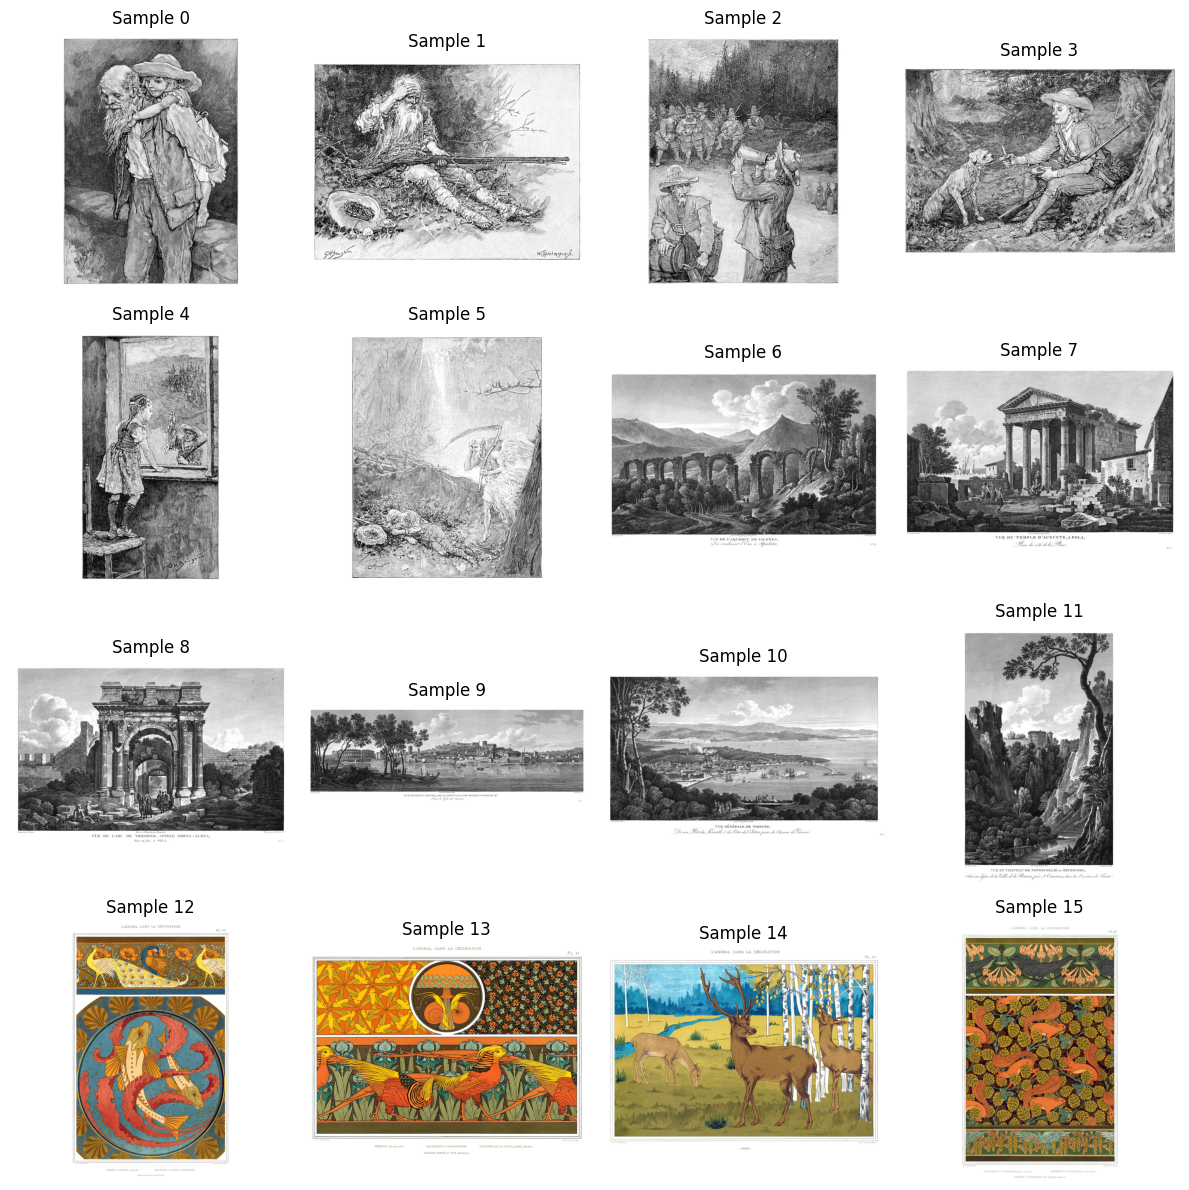

In [6]:
# Visualización de 9 portadas del dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
for i in range(16):
    img = dataset[i]["1600px"]
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(f"Sample {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 5. Transformaciones (imágenes no cuadradas)
Convertimos las imágenes a un formato que Stable Diffusion pueda usar.

In [7]:
# resolución final para entrenamiento en GPU

resolution = 512

image_transforms = transforms.Compose([
    transforms.Resize(resolution),
    transforms.CenterCrop((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

#### 6. Tokenizer
Cargamos el tokenizer de CLIP, que convierte texto en tokens numéricos.

In [8]:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder="tokenizer")

#### 7. Dataset wrapper adaptado


In [9]:
class OldBookDataset(Dataset):
    """
    Dataset para el finetuning:
    - Usa la columna '1600px' como imagen
    - Usa la columna 'info_alt' como descripción
    - Convierte todas las imágenes a RGB (aunque algunas sean B/N)
    """ 

    def __init__(self, hf_dataset, tokenizer, image_transforms):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]

        # Imagen: columna '1600px', convertida a RGB
        image: Image.Image = example["1600px"].convert("RGB")
        image = self.image_transforms(image)

        # Texto: columna 'info_alt'
        text = example["info_alt"]

        tokens = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids.squeeze(0),
            "attention_mask": tokens.attention_mask.squeeze(0),
        }

train_dataset = OldBookDataset(dataset, tokenizer, image_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

len(train_dataset), next(iter(train_dataloader))["pixel_values"].shape

(200, torch.Size([1, 3, 512, 512]))

#### 8. Cargar componentes del modelo base

In [11]:
noise_scheduler = DDPMScheduler.from_pretrained(
    pretrained_model_name,
    subfolder="scheduler"
)

text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
    torch_dtype=torch.float32
).to(device)

# Liberar VAE previo si existe
try:
    del vae
except:
    pass

import gc
gc.collect()
torch.cuda.empty_cache()

# Cargar VAE forzándolo a CPU
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
    torch_dtype=torch.float32,
    device_map={"": "cpu"},   # ← fuerza CPU de verdad
    low_cpu_mem_usage=True    # ← requerido por Diffusers
)

vae.eval()

for p in vae.parameters():
    p.requires_grad = False

print("VAE device:", next(vae.parameters()).device)


unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
    torch_dtype=torch.float32
).to(device)

print("UNet:", next(unet.parameters()).device, next(unet.parameters()).dtype)

Taking `'Attention' object has no attribute 'key'` while using `accelerate.load_checkpoint_and_dispatch` to mean CompVis/stable-diffusion-v1-4 was saved with deprecated attention block weight names. We will load it with the deprecated attention block names and convert them on the fly to the new attention block format. Please re-save the model after this conversion, so we don't have to do the on the fly renaming in the future. If the model is from a hub checkpoint, please also re-upload it or open a PR on the original repository.


VAE device: cpu
UNet: cuda:0 torch.float32


#### 9. Congelar VAE y Text Encoder (Transfer learning)
No queremos entrenar VAE ni text encoder, solo la UNet

In [12]:
vae.eval()
text_encoder.eval()

for p in vae.parameters():
    p.requires_grad = False

for p in text_encoder.parameters():
    p.requires_grad = False

#### 10. Preparar entrenamiento
En este caso el num_epochs lo ajustamos a 2, tal cual como lo sugiere el enunciado del ejercicio.

In [13]:
learning_rate = 1e-5
num_epochs = 2

# Optimizador (solo entrena la UNet)
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

In [14]:
print(text_encoder.device)

cuda:0


#### 11. Bucle de entrenamiento (finetuning)
En esta seccion la UNet aprende a generar imágenes del estilo del dataset.

In [15]:
!nvidia-smi

Fri Jun 19 12:06:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   39C    P8             15W /  140W |    4965MiB /   8192MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
print("UNet:", next(unet.parameters()).device, next(unet.parameters()).dtype)
print("Text Encoder:", next(text_encoder.parameters()).device, next(text_encoder.parameters()).dtype)
print("VAE:", next(vae.parameters()).device, next(vae.parameters()).dtype)

UNet: cuda:0 torch.float32
Text Encoder: cuda:0 torch.float32
VAE: cpu torch.float32


In [17]:
print("VAE device:", next(vae.parameters()).device)

VAE device: cpu


In [19]:
batch = next(iter(train_dataloader))

with torch.no_grad():
    pixel_values = batch["pixel_values"]  # CPU float32
    latents = vae.encode(pixel_values).latent_dist.sample()
    latents = latents * 0.18215

latents = latents.to(device)  # GPU float32

noise = torch.randn_like(latents)
timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (latents.shape[0],),
    device=device,
).long()

noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

input_ids = batch["input_ids"].to(device)
encoder_hidden_states = text_encoder(input_ids)[0]  # GPU float32

print("latents:", latents.device, latents.dtype)
print("noisy_latents:", noisy_latents.device, noisy_latents.dtype)
print("encoder_hidden_states:", encoder_hidden_states.device, encoder_hidden_states.dtype)

# Prueba UNet
out = unet(noisy_latents, timesteps, encoder_hidden_states).sample
print("UNet output:", out.device, out.dtype)

latents: cuda:0 torch.float32
noisy_latents: cuda:0 torch.float32
encoder_hidden_states: cuda:0 torch.float32
UNet output: cuda:0 torch.float32


In [ ]:
unet.train()

for epoch in range(num_epochs):
    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        leave=True,
    )

    for batch in progress_bar:
        with torch.no_grad():
            pixel_values = batch["pixel_values"]  # CPU float32  ← CORRECTO
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215

        latents = latents.to(device)  # GPU float32

        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=device,
        ).long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        input_ids = batch["input_ids"].to(device)
        encoder_hidden_states = text_encoder(input_ids)[0]

        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())

Epoch 1/2:   0%|          | 0/200 [00:00<?, ?it/s]

#### 12. Guardar el modelo UNet finetuneado
Guardamos la UNet finetuneada en una carpeta de nuestro equipo.

In [ ]:
save_path = "./sd-oldbook-finetuned-unet-wGPU-512-200"
os.makedirs(save_path, exist_ok=True)

unet.save_pretrained(save_path)
print("UNet finetuneada guardada en:", save_path)

#### 13. Cuantización ligera para inferencia (FP16)
Nota: esto es para uso en inferencia, no reentrenes en FP16 si tu entorno no está preparado.

In [ ]:
# Cargar la UNet finetuneada en FP16 (GPU)
unet_fp16 = UNet2DConditionModel.from_pretrained(
    save_path,
    torch_dtype=torch.float16
).to("cuda")

# Cargar el pipeline base
pipe_finetuned = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    torch_dtype=torch.float32  # IMPORTANTE: evita que CLIP y VAE pasen a FP16
)

# Reemplazar la UNet por la finetuneada (FP16)
pipe_finetuned.unet = unet_fp16

# Mover todo el pipeline a GPU
pipe_finetuned = pipe_finetuned.to("cuda")

# Activar xFormers si está disponible
try:
    pipe_finetuned.enable_xformers_memory_efficient_attention()
    print("xFormers activado.")
except:
    print("xFormers no disponible.")

print("Pipeline finetuneado cargado en GPU (UNet FP16, resto FP32).")

#### 14. Subir la UNet finuteado a Hugging Face
Subimos la carpeta del modelo finetuneado a nuestro repositorio personal, ubicado en *https://huggingface.co/*

In [ ]:
repo_id = "alexdesousa/sd-oldbook-finetuned-wGPU-512-200"

upload_folder(
    folder_path=save_path,
    repo_id=repo_id,
    repo_type="model"
)

print("Modelo UNet finetuneado subido correctamente a Hugging Face:", repo_id)

#### 15. Generar imágenes antes/después

***Antes del finetuning:***  
Generamos una imagen con el modelo original.

In [ ]:
# Cargar el modelo base en GPU (solo UNet en FP16)
pipe_base = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    torch_dtype=torch.float32   # CLIP y VAE en FP32
).to("cuda")

# Convertir solo la UNet a FP16
pipe_base.unet.to(dtype=torch.float16)

# Activar xFormers si está disponible
try:
    pipe_base.enable_xformers_memory_efficient_attention()
except:
    pass

prompt = "a haunting 19th century engraved illustration of a child walking through a shadowy forest, twisted trees and hidden eyes in the darkness, ornate victorian frame, dense cross‑hatching, dramatic shadows, vintage ink engraving, eerie atmosphere"

# Seed fija para comparación justa
generator = torch.Generator(device="cuda").manual_seed(42)

# Generar imagen con el modelo original
image_before = pipe_base(prompt, generator=generator).images[0]
image_before.save("modelo_Original-wGPU-512-200.png")

image_before

***Después del finetuning:***  
Generamos la misma imagen con el modelo finetuneado.

In [ ]:
# Usamos el mismo prompt y la misma seed
generator = torch.Generator(device="cuda").manual_seed(42)

image_after = pipe_finetuned(prompt, generator=generator).images[0]
image_after.save("modelo_Modificado-wGPU-512-200.png")

image_after